# BGC-Argo Profile Regridding (1 dbar)

## Interpolating and regridding float data to 1 decibar z-levels

In [1]:
# Imports
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import xarray as xr
import gsw
import datetime
import time
import matplotlib.pyplot as plt

In [2]:
# Load Argo/BGC data for your region and time window
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'
BGC_schema = pq.read_schema(parquet_dir + "_common_metadata")

# Region bounds (example: SW Pacific, crosses the dateline)
lat0, lat1 = -60, -40
lon0, lon1 = 150, -140

start = datetime.datetime(2022, 6, 1)
end = datetime.datetime(2024, 6, 1)

needed_columns = [
    "PLATFORM_NUMBER", "CYCLE_NUMBER", "JULD", "LATITUDE", "LONGITUDE",
    "PRES", "PRES_QC",
    "TEMP", "TEMP_QC",
    "PSAL", "PSAL_QC",
    "DOXY", "DOXY_QC",
    "CHLA", "CHLA_QC",
    "ABS_SAL_COMPUTED", "CONSERVATIVE_TEMP_COMPUTED",
]

# Two filters needed since the box crosses the antimeridian (dateline)
filters_east = [
    ("JULD", ">=", start), ("JULD", "<", end),
    ("LATITUDE", ">", lat0), ("LATITUDE", "<", lat1),
    ("LONGITUDE", ">", 150), ("LONGITUDE", "<=", 180),
]
filters_west = [
    ("JULD", ">=", start), ("JULD", "<", end),
    ("LATITUDE", ">", lat0), ("LATITUDE", "<", lat1),
    ("LONGITUDE", ">", -180), ("LONGITUDE", "<", -140),
]

ds_east = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters_east)
df_east = ds_east.read(columns=needed_columns).to_pandas()

ds_west = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters_west)
df_west = ds_west.read(columns=needed_columns).to_pandas()

df_swp_croco = pd.concat([df_east, df_west], ignore_index=True)
print(df_swp_croco.shape)
print(df_swp_croco["PLATFORM_NUMBER"].nunique(), "unique floats")
print(df_swp_croco.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"]).ngroups, "unique profiles")

(672619, 17)
39 unique floats
994 unique profiles


In [3]:
# Regridding function — interpolates one variable onto a fixed 1-dbar axis
def regrid_variable(pres_vals, param_vals, intp_pres):
    """Linear interpolation onto a fixed pressure axis, no extrapolation beyond
    the original data's own pressure range."""
    pres_vals = np.asarray(pres_vals, dtype=float)
    param_vals = np.asarray(param_vals, dtype=float)
    valid = np.isfinite(pres_vals) & np.isfinite(param_vals)
    if valid.sum() < 2:
        return np.full(len(intp_pres), np.nan)
    p, v = pres_vals[valid], param_vals[valid]
    sort_idx = np.argsort(p)
    p, v = p[sort_idx], v[sort_idx]
    interp_vals = np.interp(intp_pres, p, v, left=np.nan, right=np.nan)
    interp_vals[(intp_pres < p.min()) | (intp_pres > p.max())] = np.nan
    return interp_vals

In [8]:
# Regrid every profile, every variable, independently onto a shared depth axis

max_depth = 1000
intp_pres = np.arange(0, max_depth + 1, 1)  # target axis: 0-1000 dbar, 1 dbar steps (1001 levels)

# Group the full depth-resolved dataframe into one group per profile (platform + cycle)
profile_groups = df_swp_croco.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"])
n_profiles = profile_groups.ngroups  # total number of distinct profiles to process

# Lists to accumulate metadata for each successfully-processed profile
platform_list, cycle_list = [], []
juld_list, lat_list, lon_list = [], [], []

# Lists to accumulate the regridded 1D arrays for each variable, one array per profile
temp_arr, ptemp_arr, sal_arr, doxy_arr, o2sat_arr, aou_arr, chla_arr = [], [], [], [], [], [], []

t0 = time.time()       # start time, for tracking overall progress/speed
n_failed = 0            # counter for profiles that raise an exception during processing

# Loop over every profile (one iteration = one platform+cycle combination)
for i, ((pid, cyc), df_p) in enumerate(profile_groups):
    try:
        # Extract this profile's raw pressure and position values as plain float arrays
        pres_full = df_p["PRES"].values.astype(float)
        lat_p = df_p["LATITUDE"].values.astype(float)
        lon_p = df_p["LONGITUDE"].values.astype(float)

        # Extract the core variables needed for TEOS-10 derived-quantity calculations
        SA = df_p["ABS_SAL_COMPUTED"].values.astype(float)         # Absolute Salinity (pre-computed in source)
        CT = df_p["CONSERVATIVE_TEMP_COMPUTED"].values.astype(float)  # Conservative Temperature (pre-computed)
        TEMP_raw = df_p["TEMP"].values.astype(float)                # in-situ temperature
        DOXY_raw = df_p["DOXY"].values.astype(float)                # measured dissolved oxygen
        CHLA_raw = df_p["CHLA"].values.astype(float)                # measured chlorophyll-a

        # Potential temperature: only computable where SA, TEMP, and PRES are all valid together
        valid_gsw = np.isfinite(SA) & np.isfinite(TEMP_raw) & np.isfinite(pres_full)
        theta = np.full_like(pres_full, np.nan)  # start as all-NaN, same shape as the raw pressure array
        if valid_gsw.any():
            # gsw.pt0_from_t needs matched, fully-valid SA/TEMP/PRES triplets — pass only the valid subset
            theta[valid_gsw] = gsw.pt0_from_t(SA[valid_gsw], TEMP_raw[valid_gsw], pres_full[valid_gsw])

        # Oxygen saturation concentration: needs SA, CT, PRES, and position (lat/lon) all valid
        valid_o2 = (
            np.isfinite(SA) & np.isfinite(CT) & np.isfinite(pres_full) &
            np.isfinite(lat_p) & np.isfinite(lon_p)
        )
        O2_sol = np.full_like(pres_full, np.nan)  # start as all-NaN
        if valid_o2.any():
            # gsw.O2sol computes the saturation concentration at 1 atm for these water properties/location
            O2_sol[valid_o2] = gsw.O2sol(
                SA[valid_o2], CT[valid_o2], pres_full[valid_o2], lon_p[valid_o2], lat_p[valid_o2]
            )

        # Apparent Oxygen Utilization: saturation minus observed — NaN wherever either input is NaN
        AOU = O2_sol - DOXY_raw

        # Record this profile's metadata (one value per profile)
        platform_list.append(pid)
        cycle_list.append(cyc)
        juld_list.append(df_p["JULD"].iloc[0])       # profile date (same for every row in this group)
        lat_list.append(df_p["LATITUDE"].iloc[0])    # profile's latitude
        lon_list.append(df_p["LONGITUDE"].iloc[0])   # profile's longitude

        # Regrid each variable independently onto the fixed 1-dbar axis
        # each call uses ONLY that variable's own valid (pres, value) pairs, so one variable's
        # missing data (e.g. no DOXY at a given depth) never discards another variable's real data
        temp_arr.append(regrid_variable(pres_full, TEMP_raw, intp_pres))
        ptemp_arr.append(regrid_variable(pres_full, theta, intp_pres))
        sal_arr.append(regrid_variable(pres_full, SA, intp_pres))
        doxy_arr.append(regrid_variable(pres_full, DOXY_raw, intp_pres))
        o2sat_arr.append(regrid_variable(pres_full, O2_sol, intp_pres))
        aou_arr.append(regrid_variable(pres_full, AOU, intp_pres))
        chla_arr.append(regrid_variable(pres_full, CHLA_raw, intp_pres))

    except Exception as e:
        n_failed += 1
        print(f"Profile {pid}/{cyc} FAILED: {type(e).__name__}: {e}")
        continue

    # Progress update
    if (i + 1) % 100 == 0:
        print(f"{i+1}/{n_profiles} done ({time.time()-t0:.1f}s elapsed)")

# Final summary: how many profiles succeeded vs. failed, and total runtime
print(f"\nDone. {len(platform_list)} succeeded, {n_failed} failed. Total time: {time.time()-t0:.1f}s")

100/994 done (0.3s elapsed)
200/994 done (0.5s elapsed)


300/994 done (0.6s elapsed)
400/994 done (0.8s elapsed)


500/994 done (1.0s elapsed)
600/994 done (1.1s elapsed)


700/994 done (1.3s elapsed)
800/994 done (1.5s elapsed)


900/994 done (1.7s elapsed)

Done. 994 succeeded, 0 failed. Total time: 1.9s


In [5]:
# Assemble into one combined xarray Dataset
ds_all_floats = xr.Dataset(
    {
        "TEMP": (("profile", "pres"), np.array(temp_arr)),
        "POTENTIAL_TEMP": (("profile", "pres"), np.array(ptemp_arr)),
        "ABS_SAL": (("profile", "pres"), np.array(sal_arr)),
        "DOXY": (("profile", "pres"), np.array(doxy_arr)),
        "O2_SATURATION": (("profile", "pres"), np.array(o2sat_arr)),
        "AOU": (("profile", "pres"), np.array(aou_arr)),
        "CHLA": (("profile", "pres"), np.array(chla_arr)),
    },
    coords={
        "pres": intp_pres,
        "profile": np.arange(len(platform_list)),
        "PLATFORM_NUMBER": ("profile", np.array(platform_list)),
        "CYCLE_NUMBER": ("profile", np.array(cycle_list)),
        "JULD": ("profile", pd.to_datetime(juld_list)),
        "LATITUDE": ("profile", np.array(lat_list)),
        "LONGITUDE": ("profile", np.array(lon_list)),
    },
    attrs={"region": "swp", "depth_units": "decibar", "max_depth": max_depth},
)

print(ds_all_floats)

<xarray.Dataset> Size: 56MB
Dimensions:          (profile: 994, pres: 1001)
Coordinates:
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
  * profile          (profile) int64 8kB 0 1 2 3 4 5 ... 988 989 990 991 992 993
    PLATFORM_NUMBER  (profile) <U7 28kB '2903453' '2903453' ... '7901102'
    CYCLE_NUMBER     (profile) int64 8kB 30 31 32 33 34 35 36 ... 127 1 2 3 4 5
    JULD             (profile) datetime64[ns] 8kB 2024-01-24T13:32:45.0014412...
    LATITUDE         (profile) float64 8kB -56.33 -56.01 ... -56.45 -56.52
    LONGITUDE        (profile) float64 8kB 151.5 152.1 151.4 ... -167.9 -167.2
Data variables:
    TEMP             (profile, pres) float64 8MB nan nan nan ... 2.659 2.658
    POTENTIAL_TEMP   (profile, pres) float64 8MB nan nan nan ... 2.594 2.593
    ABS_SAL          (profile, pres) float64 8MB nan nan nan ... 34.68 34.68
    DOXY             (profile, pres) float64 8MB nan nan nan ... 171.6 171.5
    O2_SATURATION    (profile, pres)

In [ ]:
# Save locally, then upload to S3
import s3fs

local_path = "/home/jovyan/swp_regridded_profiles_full.zarr"
ds_all_swp.to_zarr(local_path, mode="w", zarr_format=2)
print(f"Saved locally to {local_path}")

fs2 = s3fs.S3FileSystem(anon=False, skip_instance_cache=True)
s3_path = "uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_full.zarr"
fs2.put(local_path, s3_path, recursive=True)
print(f"Uploaded to s3://{s3_path}")

## Short analysis

Selected profile indices: [745 806 622 262  94]


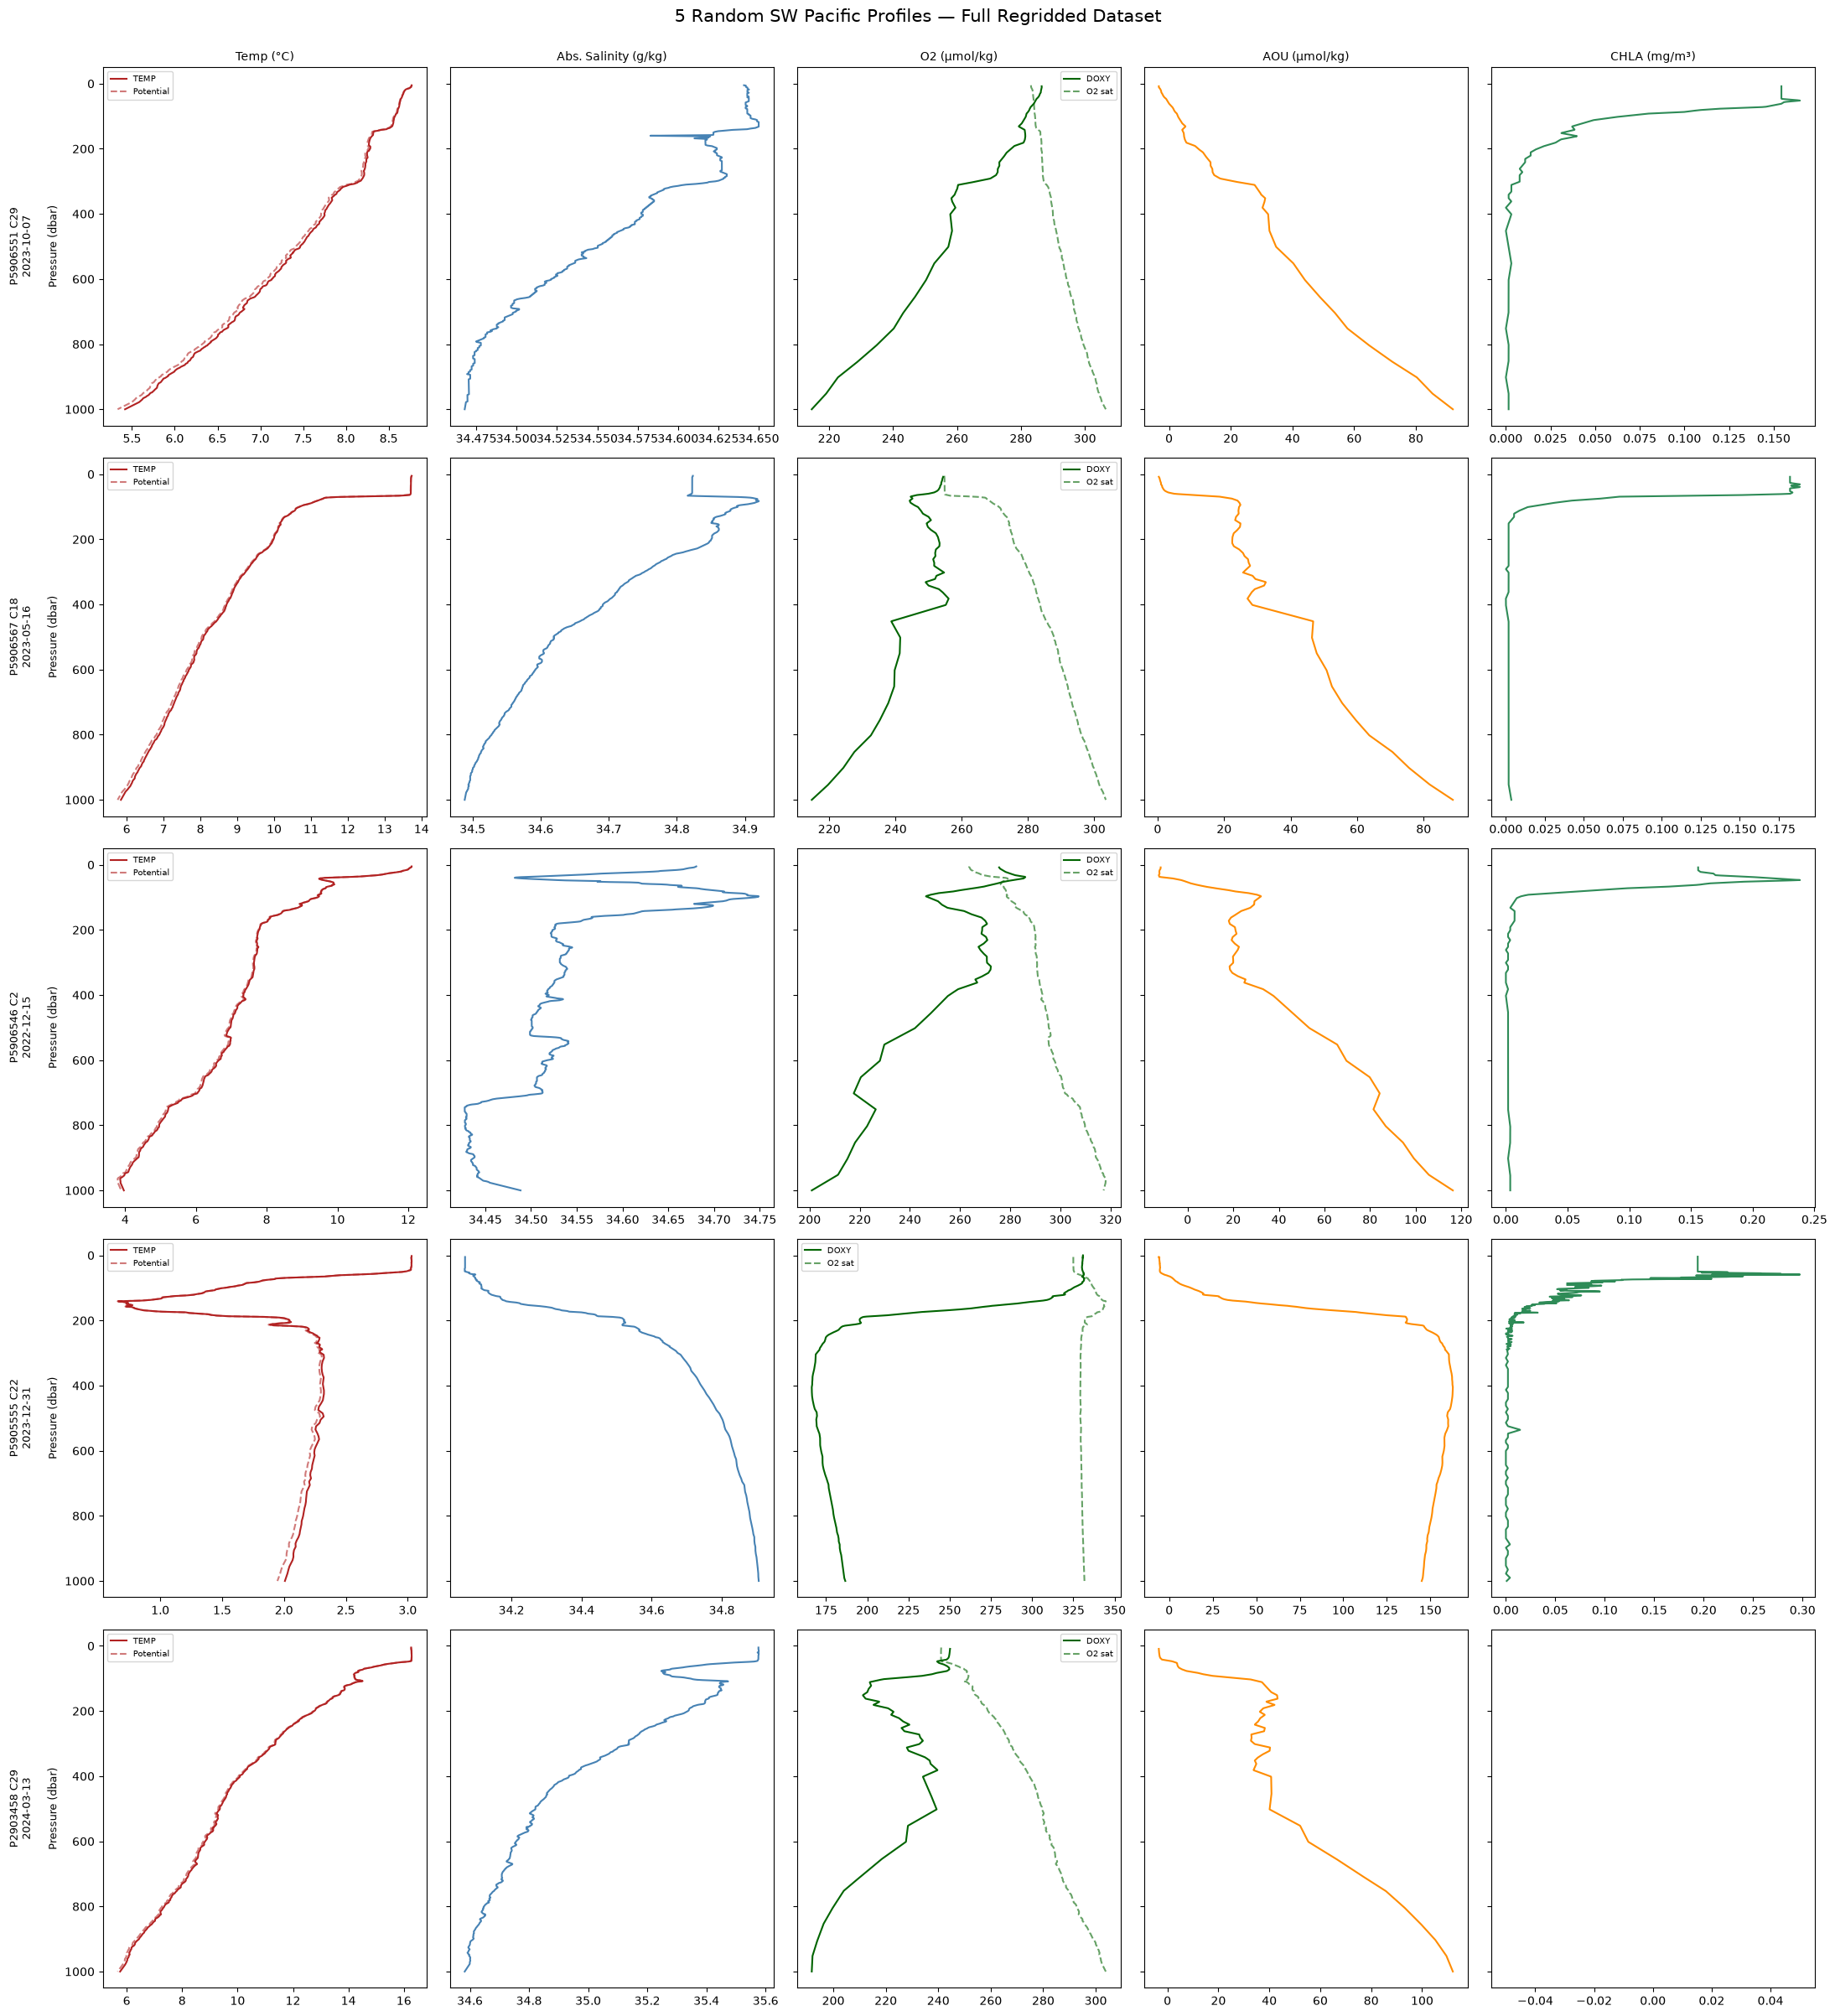

In [7]:
np.random.seed(1)
random_indices = np.random.choice(ds_all_floats.sizes["profile"], size=5, replace=False)
print("Selected profile indices:", random_indices)

fig, axes = plt.subplots(5, 5, figsize=(22, 24), sharey=True)

var_configs = [
    ("TEMP", "Temp (°C)", "firebrick", "POTENTIAL_TEMP", "Potential"),
    ("ABS_SAL", "Abs. Salinity (g/kg)", "steelblue", None, None),
    ("DOXY", "O2 (µmol/kg)", "darkgreen", "O2_SATURATION", "O2 sat"),
    ("AOU", "AOU (µmol/kg)", "darkorange", None, None),
    ("CHLA", "CHLA (mg/m³)", "seagreen", None, None),
]

for row, idx in enumerate(random_indices):
    prof = ds_all_floats.isel(profile=idx)
    pid = str(prof["PLATFORM_NUMBER"].values)
    cyc = int(prof["CYCLE_NUMBER"])
    date = str(prof["JULD"].values)[:10]

    for col, (var, xlabel, color, var2, label2) in enumerate(var_configs):
        ax = axes[row, col]
        ax.plot(prof[var], prof["pres"], color=color, label=var if var2 else None)
        if var2:
            ax.plot(prof[var2], prof["pres"], color=color, linestyle="--", alpha=0.6, label=label2)
            ax.legend(fontsize=7)
        if row == 0:
            ax.set_title(xlabel, fontsize=10)
        if col == 0:
            ax.set_ylabel(f"P{pid} C{cyc}\n{date}\n\nPressure (dbar)", fontsize=9)

axes[0, 0].invert_yaxis()
fig.suptitle("5 Random SW Pacific Profiles — Full Regridded Dataset", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import pyarrow.parquet as pq
import pandas as pd

In [2]:
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'
BGC_schema = pq.read_schema(parquet_dir + "_common_metadata")

# SW Pacific box, -180/180 convention (matching your float data)
lat0, lat1 = -60, -40
lon0, lon1 = 150, -140  # crosses the dateline — see note below

start = datetime.datetime(2022, 6, 1)
end = datetime.datetime(2024, 6, 1)

In [7]:
print(sorted(BGC_schema.names))

['ABS_SAL_COMPUTED', 'BBP', 'BBP470', 'BBP470_DATA_MODE', 'BBP470_ERROR', 'BBP470_QC', 'BBP532', 'BBP532_DATA_MODE', 'BBP532_ERROR', 'BBP532_QC', 'BBP700', 'BBP700_DATA_MODE', 'BBP700_ERROR', 'BBP700_QC', 'BBP_DATA_MODE', 'BBP_ERROR', 'BBP_QC', 'BISULFIDE', 'BISULFIDE_DATA_MODE', 'BISULFIDE_ERROR', 'BISULFIDE_QC', 'CCL4', 'CCL4_ERROR', 'CCL4_QC', 'CDOM', 'CDOM_DATA_MODE', 'CDOM_ERROR', 'CDOM_QC', 'CFC11', 'CFC113', 'CFC113_ERROR', 'CFC113_QC', 'CFC11_ERROR', 'CFC11_QC', 'CFC12', 'CFC12_ERROR', 'CFC12_QC', 'CHLA', 'CHLA_DATA_MODE', 'CHLA_ERROR', 'CHLA_QC', 'CONSERVATIVE_TEMP_COMPUTED', 'CP', 'CP660', 'CP660_DATA_MODE', 'CP660_ERROR', 'CP660_QC', 'CP_DATA_MODE', 'CP_ERROR', 'CP_QC', 'CYCLE_NUMBER', 'DATE_UPDATE', 'DB_NAME', 'DEPTH', 'DOWNWELLING_PAR', 'DOWNWELLING_PAR_DATA_MODE', 'DOWNWELLING_PAR_ERROR', 'DOWNWELLING_PAR_QC', 'DOWN_IRRADIANCE', 'DOWN_IRRADIANCE380', 'DOWN_IRRADIANCE380_DATA_MODE', 'DOWN_IRRADIANCE380_ERROR', 'DOWN_IRRADIANCE380_QC', 'DOWN_IRRADIANCE412', 'DOWN_IRRADIANCE

In [ ]:
ABS_SAL_COMPUTED
CONSERVATIVE_TEMP_COMPUTED
AOU = oxygen saturation - oxygen observed

In [8]:
needed_columns = [
    "PLATFORM_NUMBER", "CYCLE_NUMBER", "JULD", "LATITUDE", "LONGITUDE",
    "PRES", "PRES_QC",
    "TEMP", "TEMP_QC",
    "PSAL", "PSAL_QC",
    "DOXY", "DOXY_QC",
    "CHLA", "CHLA_QC",
    "BBP700", "BBP700_QC",
    "ABS_SAL_COMPUTED", "CONSERVATIVE_TEMP_COMPUTED",
]

In [3]:
# Two separate filters (OR'd together) since the box crosses the dateline
filters_east = [
    ("JULD", ">", start), ("JULD", "<", end),
    ("LATITUDE", ">", lat0), ("LATITUDE", "<", lat1),
    ("LONGITUDE", ">", 150), ("LONGITUDE", "<=", 180),
]
filters_west = [
    ("JULD", ">", start), ("JULD", "<", end),
    ("LATITUDE", ">", lat0), ("LATITUDE", "<", lat1),
    ("LONGITUDE", ">", -180), ("LONGITUDE", "<", -140),
]

ds_east = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters_east)
df_east = ds_east.read(columns=["PLATFORM_NUMBER", "CYCLE_NUMBER", "JULD", "LATITUDE", "LONGITUDE"]).to_pandas()

ds_west = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters_west)
df_west = ds_west.read(columns=["PLATFORM_NUMBER", "CYCLE_NUMBER", "JULD", "LATITUDE", "LONGITUDE"]).to_pandas()

df_swp = pd.concat([df_east, df_west], ignore_index=True)
print(df_swp.shape)

swp_floats = df_swp["PLATFORM_NUMBER"].unique()
print(f"{len(swp_floats)} unique floats in SW Pacific box")

(672619, 5)
39 unique floats in SW Pacific box


In [4]:
traj_swp = df_swp.drop_duplicates(subset=["PLATFORM_NUMBER", "CYCLE_NUMBER"]).sort_values("JULD").copy()
print(traj_swp.shape, "profiles")

(994, 5) profiles


In [6]:
print(df_swp.shape)
print(df_swp.columns.tolist())
print(df_swp.dtypes)

(672619, 5)
['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'JULD', 'LATITUDE', 'LONGITUDE']
PLATFORM_NUMBER                    string
CYCLE_NUMBER               int32[pyarrow]
JULD               timestamp[ns][pyarrow]
LATITUDE                  double[pyarrow]
LONGITUDE                 double[pyarrow]
dtype: object


In [ ]:
def regrid_profile(platform_id, cycle_number, df_profile, max_depth=1000):
    """Regrid TEMP/PSAL for a single profile onto a common 1-dbar pressure axis."""
    intp_pres = np.arange(0, max_depth + 1, 1)

    result = {"pres": intp_pres}
    for var in ["TEMP_ADJUSTED", "PSAL_ADJUSTED"]:
        qc_col = f"{var}_QC"
        valid = (
            df_profile[var].notna() & df_profile["PRES_ADJUSTED"].notna() &
            df_profile[qc_col].isin([1, 2]) & df_profile["PRES_ADJUSTED_QC"].isin([1, 2])
        )
        sub = df_profile[valid].sort_values("PRES_ADJUSTED")

        if len(sub) < 2:
            result[var] = np.full(len(intp_pres), np.nan)
            continue

        pres_vals = sub["PRES_ADJUSTED"].values
        param_vals = sub[var].values

        interp_vals = np.interp(intp_pres, pres_vals, param_vals, left=np.nan, right=np.nan)
        interp_vals[(intp_pres < pres_vals.min()) | (intp_pres > pres_vals.max())] = np.nan

        result[var] = interp_vals

    return result

In [ ]:
# =============================================================================
# Loop over all 994 profiles, build one combined Dataset
# =============================================================================
profile_groups = df_swp_depth_qc.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"])

platform_list, cycle_list = [], []
temp_arr, psal_arr, doxy_arr = [], [], []
juld_list, lat_list, lon_list = [], [], []

max_depth = 1000
intp_pres = np.arange(0, max_depth + 1, 1)

for (pid, cyc), df_profile in profile_groups:
    r = regrid_profile(pid, cyc, df_profile, max_depth=max_depth)

    platform_list.append(pid)
    cycle_list.append(cyc)
    temp_arr.append(r["TEMP_ADJUSTED"])
    psal_arr.append(r["PSAL_ADJUSTED"])
    doxy_arr.append(r["DOXY_ADJUSTED"])
    juld_list.append(df_profile["JULD"].iloc[0])
    lat_list.append(df_profile["LATITUDE"].iloc[0])
    lon_list.append(df_profile["LONGITUDE"].iloc[0])

print(f"Regridded {len(platform_list)} profiles")

In [ ]:
ds_test = xr.Dataset(
    {
        "TEMP_ADJUSTED": (("profile", "pres"), np.array(temp_arr)),
        "PSAL_ADJUSTED": (("profile", "pres"), np.array(psal_arr)),
    },
    coords={
        "pres": intp_pres,
        "profile": np.arange(len(platform_list)),
        "PLATFORM_NUMBER": ("profile", np.array(platform_list)),
        "CYCLE_NUMBER": ("profile", np.array(cycle_list)),
        "JULD": ("profile", pd.to_datetime(juld_list)),
        "LATITUDE": ("profile", np.array(lat_list)),
        "LONGITUDE": ("profile", np.array(lon_list)),
    },
    attrs={"region": "swp", "depth_units": "decibar", "max_depth": max_depth},
)

print(ds_test)